Parallel Reduction

In [1]:
!nvidia-smi

Wed Apr 15 09:35:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [4]:
%%writefile hello.cu
#include <stdio.h>
#include <cuda_runtime.h>

__global__ void hello() {
    printf("Hello from CUDA thread %d\n", threadIdx.x);
}

int main() {
    hello<<<1, 5>>>();
    cudaDeviceSynchronize();
    return 0;
}


Writing hello.cu


In [5]:
!nvcc hello.cu -o hello

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [6]:
!./hello

Hello from CUDA thread 0
Hello from CUDA thread 1
Hello from CUDA thread 2
Hello from CUDA thread 3
Hello from CUDA thread 4


In [3]:
%%writefile reduction.cu
#include <stdio.h>
#include <cuda_runtime.h>

#define N 1024
#define THREADS 512

__global__ void reduction(int *input, int *output) {
    __shared__ int shared[THREADS];

    int tid = threadIdx.x;
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    shared[tid] = input[idx];
    __syncthreads();

    for (int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
        if (tid < stride) {
            shared[tid] += shared[tid + stride];
        }
        __syncthreads();
    }

    if (tid == 0) {
        output[blockIdx.x] = shared[0];
    }
}

int main() {
    int h_input[N];
    int h_output[N / THREADS];

    for (int i = 0; i < N; i++) {
        h_input[i] = 1;
    }

    int *d_input, *d_output;
    cudaMalloc((void**)&d_input, N * sizeof(int));
    cudaMalloc((void**)&d_output, (N / THREADS) * sizeof(int));

    cudaMemcpy(d_input, h_input, N * sizeof(int), cudaMemcpyHostToDevice);

    reduction<<<N / THREADS, THREADS>>>(d_input, d_output);

    cudaMemcpy(h_output, d_output,
               (N / THREADS) * sizeof(int),
               cudaMemcpyDeviceToHost);

    int final_sum = 0;
    for (int i = 0; i < N / THREADS; i++) {
        final_sum += h_output[i];
    }

    printf("Final sum using CUDA Parallel Reduction = %d\n", final_sum);

    cudaFree(d_input);
    cudaFree(d_output);

    return 0;
}

Writing reduction.cu


In [4]:
!nvcc reduction.cu -o reduction

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [5]:
!./reduction

Final sum using CUDA Parallel Reduction = 1024


Image Processing

In [6]:
!nvidia-smi

Wed Apr 15 10:17:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
!pip install pillow matplotlib

In [42]:
from google.colab import files
uploaded = files.upload()

Saving Image.jpg to Image.jpg


In [43]:
!ls

 grayscale	       imp.webp         reduction.cu    stb_image.h.3
 grayscale.cu	      'input (1).jpg'   sample_data     stb_image_write.h
 grayscale_simple      input.jpg        stb_image.h     stb_image_write.h.1
 grayscale_simple.cu   libgray.so       stb_image.h.1   stb_image_write.h.2
 Image.jpg	       reduction        stb_image.h.2   stb_image_write.h.3


In [44]:
!wget https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
!wget https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h

--2026-04-15 10:45:18--  https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 283010 (276K) [text/plain]
Saving to: ‘stb_image.h.4’

stb_image.h.4       100%[===================>] 276.38K  --.-KB/s    in 0.02s   

2026-04-15 10:45:18 (13.5 MB/s) - ‘stb_image.h.4’ saved [283010/283010]

--2026-04-15 10:45:18--  https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71221 (70K) [text/plain]
Saving to: ‘stb_im

In [45]:
%%writefile grayscale.cu
#include <stdio.h>
#include <cuda_runtime.h>

#define STB_IMAGE_IMPLEMENTATION
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image.h"
#include "stb_image_write.h"

__global__ void rgb2gray(unsigned char *input,
                         unsigned char *output,
                         int width, int height) {

    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x < width && y < height) {
        int rgb_idx = (y * width + x) * 3;
        int gray_idx = y * width + x;

        unsigned char r = input[rgb_idx];
        unsigned char g = input[rgb_idx + 1];
        unsigned char b = input[rgb_idx + 2];

        output[gray_idx] =
            (unsigned char)(0.299f*r + 0.587f*g + 0.114f*b);
    }
}

int main() {
    int width, height, channels;

    unsigned char *h_img =
        stbi_load("image.jpg", &width, &height, &channels, 3);

    if (!h_img) {
        printf("Failed to load image\n");
        return 1;
    }

    int img_size = width * height * 3;
    int gray_size = width * height;

    unsigned char *h_gray =
        (unsigned char*)malloc(gray_size);

    unsigned char *d_img, *d_gray;
    cudaMalloc(&d_img, img_size);
    cudaMalloc(&d_gray, gray_size);

    cudaMemcpy(d_img, h_img, img_size,
               cudaMemcpyHostToDevice);

    dim3 threads(16, 16);
    dim3 blocks((width + 15)/16,
                (height + 15)/16);

    rgb2gray<<<blocks, threads>>>(
        d_img, d_gray, width, height);

    cudaDeviceSynchronize();

    cudaMemcpy(h_gray, d_gray, gray_size,
               cudaMemcpyDeviceToHost);

    stbi_write_png("output_gray.png",
                   width, height, 1,
                   h_gray, width);

    cudaFree(d_img);
    cudaFree(d_gray);
    stbi_image_free(h_img);
    free(h_gray);

    printf("Grayscale image saved as output_gray.png\n");
    return 0;
}

Overwriting grayscale.cu


In [46]:
!nvcc grayscale.cu -o grayscale

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
stb_image.h(4276): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

stb_image.h(5185): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

stb_image.h(6972): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

stb_image.h(6973): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^



In [49]:
!./grayscale

Failed to load image


In [54]:
from PIL import Image
import numpy as np

# Create a simple RGB test image
img = np.zeros((256, 256, 3), dtype=np.uint8)
img[:, :, 0] = 255      # Red channel
img[64:192, 64:192, 1] = 255  # Green square
img[96:160, 96:160, 2] = 255  # Blue square

Image.fromarray(img).save("image.png")
print("Created input.png")

Created input.png


In [55]:
!ls -lh image.png

-rw-r--r-- 1 root root 794 Apr 15 10:50 image.png


In [59]:
%%writefile grayscale.cu
#include <stdio.h>
#include <cuda_runtime.h>

#define STB_IMAGE_IMPLEMENTATION
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image.h"
#include "stb_image_write.h"

__global__ void rgb2gray(unsigned char *input,
                         unsigned char *output,
                         int width, int height) {

    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x < width && y < height) {
        int rgb_idx = (y * width + x) * 3;
        int gray_idx = y * width + x;

        unsigned char r = input[rgb_idx];
        unsigned char g = input[rgb_idx + 1];
        unsigned char b = input[rgb_idx + 2];

        output[gray_idx] =
            (unsigned char)(0.299f*r + 0.587f*g + 0.114f*b);
    }
}

int main() {
    int width, height, channels;

    unsigned char *h_img =
        stbi_load("image.png", &width, &height, &channels, 3);

    if (!h_img) {
        printf("Failed to load image: %s\n",
               stbi_failure_reason());
        return 1;
    }

    int img_size = width * height * 3;
    int gray_size = width * height;

    unsigned char *h_gray =
        (unsigned char*)malloc(gray_size);

    unsigned char *d_img, *d_gray;
    cudaMalloc(&d_img, img_size);
    cudaMalloc(&d_gray, gray_size);

    cudaMemcpy(d_img, h_img, img_size,
               cudaMemcpyHostToDevice);

    dim3 threads(16,16);
    dim3 blocks((width+15)/16,(height+15)/16);

    rgb2gray<<<blocks,threads>>>(d_img,d_gray,width,height);
    cudaDeviceSynchronize();

    cudaMemcpy(h_gray,d_gray,gray_size,
               cudaMemcpyDeviceToHost);

    stbi_write_png("output_gray.png",
                   width,height,1,
                   h_gray,width);

    cudaFree(d_img);
    cudaFree(d_gray);
    stbi_image_free(h_img);
    free(h_gray);

    printf("Grayscale image saved as output_gray.png\n");
    return 0;
}

Overwriting grayscale.cu


In [60]:
!nvcc grayscale.cu -o grayscale

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
stb_image.h(4276): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

stb_image.h(5185): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

stb_image.h(6972): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

stb_image.h(6973): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^



In [61]:
!./grayscale

Grayscale image saved as output_gray.png


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

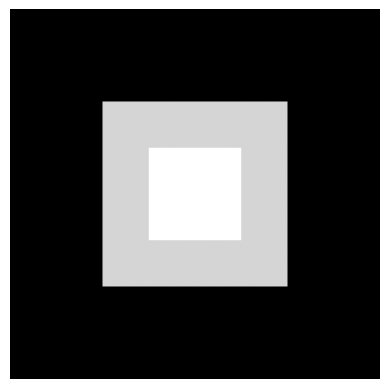

In [62]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("output_gray.png")
plt.imshow(img, cmap="gray")
plt.axis("off")